In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Cấu hình plot
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

In [ ]:
# Đọc dữ liệu features từ file CSV
data_path = '/workspace/data/taxi_demand_features.csv'
df = pd.read_csv(data_path)

print(f"Kích thước dữ liệu: {df.shape}")
display(df.head())

# Sắp xếp theo: Phân vùng (Borough) -> Năm -> Tháng -> Thứ trong tuần -> Giờ
df = df.sort_values(by=['borough_idx', 'year', 'month', 'day_of_week', 'hour']).reset_index(drop=True)
display(df.head())

Kích thước dữ liệu: (59426, 6)


,borough_idx,year,month,day_of_week,hour,busy_score
0,0.0,2020,1,4,5,8594
1,0.0,2020,1,4,11,45165
2,1.0,2020,1,6,23,2935
3,2.0,2020,1,6,21,495
4,0.0,2020,1,7,15,42789


,borough_idx,year,month,day_of_week,hour,busy_score
0,0.0,2020,1,1,0,35473
1,0.0,2020,1,1,1,31344
2,0.0,2020,1,1,2,24432
3,0.0,2020,1,1,3,16679
4,0.0,2020,1,1,4,9161


In [ ]:
def calculate_sma(series, window=3):
    """
    Simple Moving Average (SMA)
    Dự đoán t = trung bình của (t-1, t-2, ..., t-window)
    """
    return series.shift(1).rolling(window=window).mean()

def calculate_wma(series, window=3):
    """
    Weighted Moving Average (WMA)
    Trọng số tăng dần cho các thời điểm gần hiện tại nhất.
    Ví dụ window=3: w = [1, 2, 3] -> sum = 6
    Pred_t = (3*Y_{t-1} + 2*Y_{t-2} + 1*Y_{t-3}) / 6
    """
    weights = np.arange(1, window + 1)
    
    def wma_calc(x):
        return np.sum(weights * x) / weights.sum()
        
    return series.shift(1).rolling(window=window).apply(wma_calc, raw=True)

def calculate_ema(series, span=3):
    """
    Exponential Moving Average (EMA)
    Trọng số giảm dần theo cấp số nhân đối với quá khứ.
    """
    return series.shift(1).ewm(span=span, adjust=False).mean()

In [ ]:
WINDOW = 4 # Dùng 4 mốc thời gian gần nhất để dự đoán

results = []

# Xử lý song song cho từng Borough để tránh rò rỉ dữ liệu (data leakage) giữa các vùng
for borough in df['borough_idx'].unique():
    mask = df['borough_idx'] == borough
    subset = df[mask].copy()
    
    # Tính toán các Moving Averages
    subset['SMA'] = calculate_sma(subset['busy_score'], window=WINDOW)
    subset['WMA'] = calculate_wma(subset['busy_score'], window=WINDOW)
    subset['EMA'] = calculate_ema(subset['busy_score'], span=WINDOW)
    
    results.append(subset)

# Nối lại thành dataframe tổng
df_pred = pd.concat(results).reset_index(drop=True)

df_pred_clean = df_pred.dropna().copy()

In [7]:
def evaluate_baseline(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

# Đánh giá trên toàn bộ tập dữ liệu
eval_results = [
    evaluate_baseline(df_pred_clean['busy_score'], df_pred_clean['SMA'], 'Simple Moving Average (SMA)'),
    evaluate_baseline(df_pred_clean['busy_score'], df_pred_clean['WMA'], 'Weighted Moving Average (WMA)'),
    evaluate_baseline(df_pred_clean['busy_score'], df_pred_clean['EMA'], 'Exponential Moving Average (EMA)')
]

eval_df = pd.DataFrame(eval_results)
display(eval_df.style.highlight_min(subset=['RMSE', 'MAE'], color='lightgreen')\
               .highlight_max(subset=['R2'], color='lightgreen'))

,Model,RMSE,MAE,R2
0,Simple Moving Average (SMA),3068.650511,1165.247235,0.855152
1,Weighted Moving Average (WMA),2550.063869,959.196323,0.899973
2,Exponential Moving Average (EMA),2745.168057,1073.707947,0.884081


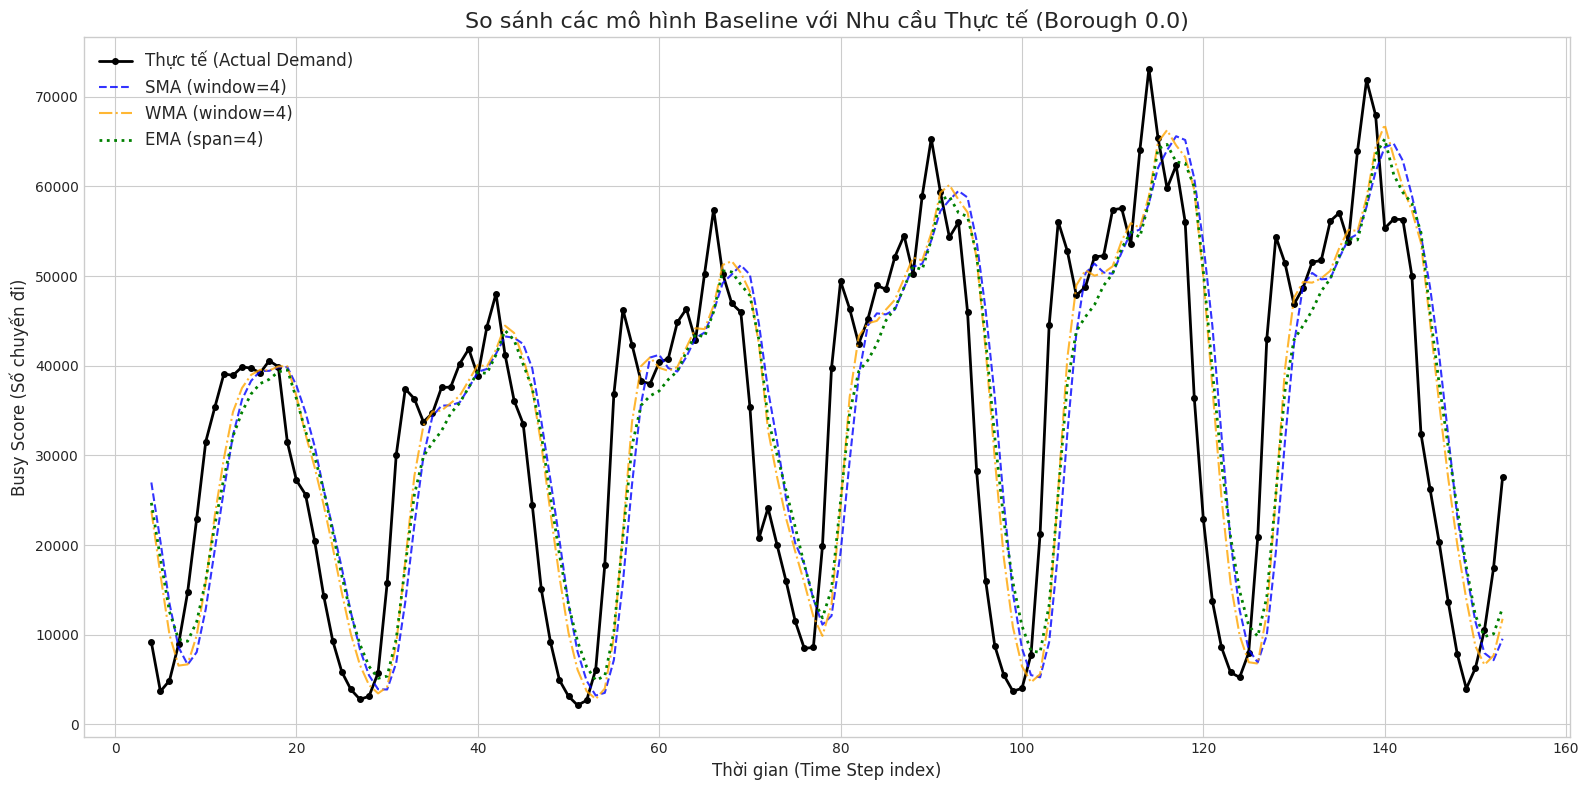

In [ ]:
sample_plot = df_pred_clean[df_pred_clean['borough_idx'] == 0.0].head(150)

plt.figure(figsize=(16, 8))

plt.plot(sample_plot.index, sample_plot['busy_score'], label='Thực tế (Actual Demand)', color='black', linewidth=2, marker='o', markersize=4)
plt.plot(sample_plot.index, sample_plot['SMA'], label=f'SMA (window={WINDOW})', linestyle='--', color='blue', alpha=0.8)
plt.plot(sample_plot.index, sample_plot['WMA'], label=f'WMA (window={WINDOW})', linestyle='-.', color='orange', alpha=0.8)
plt.plot(sample_plot.index, sample_plot['EMA'], label=f'EMA (span={WINDOW})', linestyle=':', color='green', linewidth=2)

plt.title('So sánh các mô hình Baseline với Nhu cầu Thực tế (Borough 0.0)', fontsize=16)
plt.xlabel('Thời gian (Time Step index)', fontsize=12)
plt.ylabel('Busy Score (Số chuyến đi)', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()